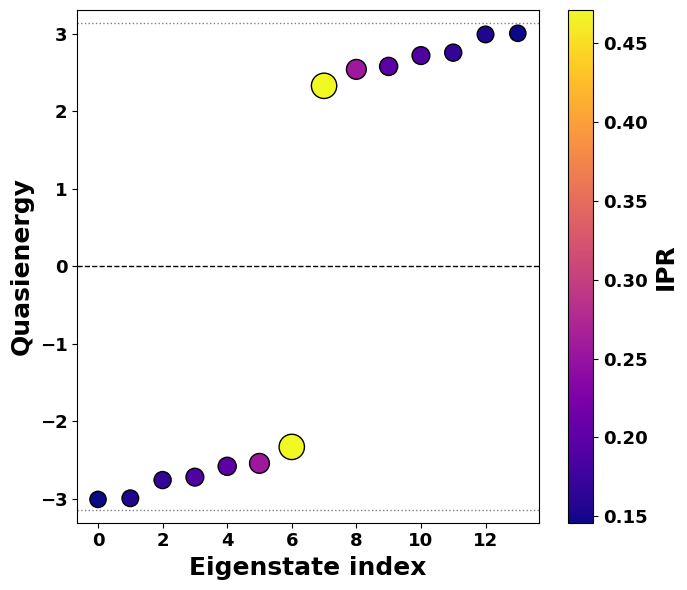

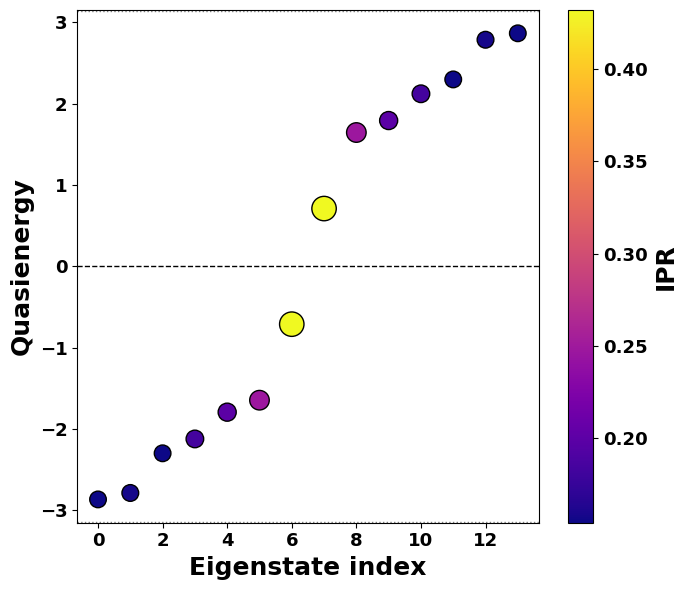

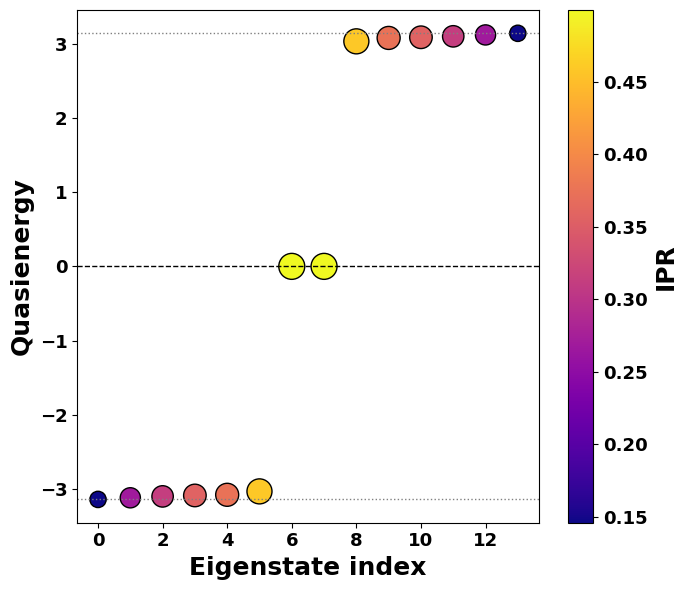

In [1]:
import numpy as np
import matplotlib.pyplot as plt

P = 7
T = 2

def coin(gamma):
    
    theta = T * gamma / 2
    
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ], dtype=complex)

def build_shifts(P):

    Splus = np.zeros((2*P, 2*P), dtype=complex)
    Sminus = np.zeros((2*P, 2*P), dtype=complex)

    for x in range(P):

        # S+ :
        # |x,0> -> |x+1,0>
        Splus[2*((x+1) % P), 2*x] = 1

        # |x,1> -> |x,1>
        Splus[2*x+1, 2*x+1] = 1


        # S- :
        # |x,1> -> |x-1,1>
        Sminus[2*((x-1) % P)+1, 2*x+1] = 1

        # |x,0> -> |x,0>
        Sminus[2*x, 2*x] = 1

    return Splus, Sminus


Splus, Sminus = build_shifts(P)

def build_coin_operator(gamma):

    C = np.zeros((2*P, 2*P), dtype=complex)

    for x in range(P):
        C[2*x:2*x+2, 2*x:2*x+2] = coin(gamma[x])

    return C


def build_floquet(gamma):

    C = build_coin_operator(gamma)

    # SCSS-CQW Floquet operator
    U = Splus @ C @ Sminus @ C

    return U



def spectrum_IPR(gamma):

    U = build_floquet(gamma)

    # Diagonalize Floquet operator
    eigval, eigvec = np.linalg.eig(U)

    # Quasienergy
    E = -np.angle(eigval)

    # Sort by quasienergy
    order = np.argsort(E)

    E = E[order]
    eigvec = eigvec[:, order]

    IPR = np.zeros(2*P)

    for n in range(2*P):

        psi = eigvec[:, n]

        # Position probability
        Px = np.zeros(P)

        for x in range(P):

            Px[x] = (
                abs(psi[2*x])**2 +
                abs(psi[2*x+1])**2
            )

        # Normalize
        Px /= np.sum(Px)

        # IPR
        IPR[n] = np.sum(Px**2)

    return E, IPR

def plot_spectrum(gamma, title):

    E, IPR = spectrum_IPR(gamma)

    eigen_index = np.arange(2*P)

    plt.figure(figsize=(7, 6))

    size = 50 + 600*IPR

    sc = plt.scatter(
        eigen_index,
        E,
        c=IPR,
        s=size,
        cmap='plasma',
        edgecolors='k'
    )

    # 0 and pi quasienergy gaps
    plt.axhline(
        0,
        color='k',
        linestyle='--',
        linewidth=1
    )

    plt.axhline(
        np.pi,
        color='grey',
        linestyle=':',
        linewidth=1
    )

    plt.axhline(
        -np.pi,
        color='grey',
        linestyle=':',
        linewidth=1
    )

    plt.xlabel(
        'Eigenstate index',
        fontsize=18,
        fontweight='bold'
    )

    plt.ylabel(
        'Quasienergy',
        fontsize=18,
        fontweight='bold'
    )

    plt.xticks(
        fontsize=13,
        fontweight='bold'
    )

    plt.yticks(
        fontsize=13,
        fontweight='bold'
    )

    cbar = plt.colorbar(sc)

    cbar.set_label(
        'IPR',
        fontsize=18,
        fontweight='bold'
    )

    cbar.ax.tick_params(labelsize=13)

    for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold')

    plt.tight_layout()
    plt.show()

    return E, IPR


# ============================================================
# CASE 1 : POINT DEFECT
# gamma_0 = pi/3
# gamma_bulk = 3pi/5
# ============================================================

gamma1 = np.array([
    np.pi/3,
    3*np.pi/5,
    3*np.pi/5,
    3*np.pi/5,
    3*np.pi/5,
    3*np.pi/5,
    3*np.pi/5
])

E1, IPR1 = plot_spectrum(
    gamma1,
    'Point defect'
)


# ============================================================
# CASE 2 : POINT DEFECT, Delta omega != 0
# gamma_0 = pi + 0.2
# gamma_bulk = 3pi/4
# ============================================================

gamma2 = np.array([
    np.pi + 0.2,
    3*np.pi/4,
    3*np.pi/4,
    3*np.pi/4,
    3*np.pi/4,
    3*np.pi/4,
    3*np.pi/4
])

E2, IPR2 = plot_spectrum(
    gamma2,
    'Point defect, Delta omega != 0'
)


# ============================================================
# CASE 3 : EDGE STATE
# gamma_0,1,2,3 = pi + 1.6
# gamma_4,5,6 = 0.52 pi
# ============================================================

gamma3 = np.array([
    np.pi + 1.6,
    np.pi + 1.6,
    np.pi + 1.6,
    np.pi + 1.6,
    0.52*np.pi,
    0.52*np.pi,
    0.52*np.pi
])

E3, IPR3 = plot_spectrum(
    gamma3,
    'Edge state'
)